# Barber Skill Level Predictor — ML Pipeline
**Project:** Skill-Based Barber Role Predictor  
**Algorithm:** RandomForestClassifier (main) + DecisionTreeClassifier (baseline)  
**Target classes:** Junior / Middle / Senior / Top  
**Dataset:** 131 rows — 100 balanced + 31 borderline edge cases (incl. stagnant & trending-skills scenarios)  

### Why RandomForest?
- Handles non-linear boundaries between skill levels naturally
- Robust to correlated features (skill counts overlap)
- Built-in feature importance for interpretability
- Outperforms single Decision Tree on small datasets via bagging

### Features used (9 total — available at hiring time)
| Feature | Description | Weight logic |
|---|---|---|
| `exp_num` | Experience bracket encoded 0–4 | 0→4 ordinal |
| `skills_score` | Weighted sum of technical skills | basic×1, adv×3, expert×5 |
| `education_score` | Courses × 2 | linear |
| `basic_skills_count` | # foundation skills | classic, machine |
| `adv_skills_count` | # advanced skills | fade, beard, razor, scissors, hair_tattoo, waxing, black_mask |
| `expert_skills_count` | # specialist skills | coloring, correction, extensions, camouflage, perm |
| `total_skills_count` | Total technical skills | basic + adv + expert |
| `soft_skills_count` | # client service skills | consulting, products |
| `soft_skills_score` | Soft skills × 2 | linear |

> **Note:** `avg_rating` and `completed_bookings` exist in the dataset but are **excluded** — they are unavailable at hiring/grading time for new staff.

In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    learning_curve, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix
)
from sklearn.preprocessing import LabelEncoder

# ── Path resolution: works from both project root and ml/ directory ──────────
_CWD = os.getcwd()
if os.path.exists(os.path.join(_CWD, 'ml', 'barber_dataset.csv')):
    ML_DIR = os.path.join(_CWD, 'ml')
elif os.path.exists(os.path.join(_CWD, 'barber_dataset.csv')):
    ML_DIR = _CWD
else:
    ML_DIR = os.path.dirname(os.path.abspath('barber_grader.ipynb'))

DATASET_PATH = os.path.join(ML_DIR, 'barber_dataset.csv')
MODEL_PATH   = os.path.join(ML_DIR, 'barber_model.pkl')

# ── Skill vocabulary (must match app/ml/evaluator.py exactly) ────────────────
BASIC_SKILLS    = ['classic', 'machine']
ADVANCED_SKILLS = ['fade', 'beard', 'razor', 'scissors', 'hair_tattoo', 'waxing', 'black_mask']
EXPERT_SKILLS   = ['extensions', 'coloring', 'camouflage', 'correction', 'perm']
SOFT_SKILLS     = ['consulting', 'products']
ALL_SKILLS      = BASIC_SKILLS + ADVANCED_SKILLS + EXPERT_SKILLS + SOFT_SKILLS

EXP_MAP = {'0': 0, '1-3': 1, '3-5': 2, '5-10': 3, '10+': 4}

FEATURES = [
    'exp_num', 'skills_score', 'education_score',
    'basic_skills_count', 'adv_skills_count', 'expert_skills_count',
    'total_skills_count', 'soft_skills_count', 'soft_skills_score',
]

CLASS_ORDER = ['Junior', 'Middle', 'Senior', 'Top']
PALETTE     = {'Junior': '#60a5fa', 'Middle': '#4ade80',
               'Senior': '#f59e0b', 'Top': '#a78bfa'}
BAR_COLORS  = [PALETTE[c] for c in CLASS_ORDER]

print(f'ML_DIR       : {ML_DIR}')
print(f'DATASET_PATH : {DATASET_PATH}')
print(f'MODEL_PATH   : {MODEL_PATH}')
print(f'Features     : {len(FEATURES)} ({FEATURES})')
print('All imports OK')

ML_DIR       : /Users/mac/backend_fastapi/ml
DATASET_PATH : /Users/mac/backend_fastapi/ml/barber_dataset.csv
MODEL_PATH   : /Users/mac/backend_fastapi/ml/barber_model.pkl
Features     : 9 (['exp_num', 'skills_score', 'education_score', 'basic_skills_count', 'adv_skills_count', 'expert_skills_count', 'total_skills_count', 'soft_skills_count', 'soft_skills_score'])
All imports OK


## 1. Dataset Loading & Exploration

Shape: (131, 7)

Label distribution:
label
Senior    37
Middle    37
Top       30
Junior    27
Name: count, dtype: int64


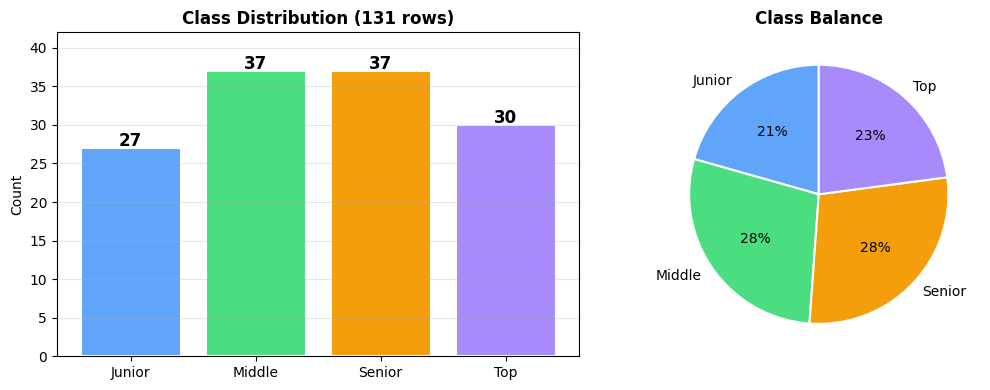

Saved: class_distribution.png


,years_experience_cat,skills,education_count,courses,avg_rating,completed_bookings,label
0,10+,"correction,perm,products,fade,black_mask,hair_...",7,"Advanced Razor Techniques,Fade Mastery,Barberi...",4.7,338,Top
1,3-5,"coloring,correction,extensions,camouflage,classic",4,"Barbering Basics,Color Theory,Fade Mastery,Men...",4.5,200,Senior
2,10+,"correction,perm,products,fade,waxing,coloring,...",7,"Barbering Basics,Beard Styling Pro,Color Theor...",4.8,578,Top
3,3-5,"hair_tattoo,products,classic,fade",1,Salon Management,4.1,93,Middle
4,0,machine,1,Color Theory,3.5,23,Junior


In [20]:
df = pd.read_csv(DATASET_PATH)
print(f'Shape: {df.shape}')
print(f"\nLabel distribution:\n{df['label'].value_counts()}")

# Class distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

vc = df['label'].value_counts().reindex(CLASS_ORDER)
axes[0].bar(vc.index, vc.values, color=BAR_COLORS, edgecolor='white', linewidth=1.5)
axes[0].set_title(f'Class Distribution ({len(df)} rows)', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, vc.max() + 5)
axes[0].grid(axis='y', alpha=0.3)

axes[1].pie(vc.values, labels=vc.index, colors=BAR_COLORS,
            autopct='%1.0f%%', startangle=90,
            wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
axes[1].set_title('Class Balance', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(ML_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print('Saved: class_distribution.png')

df.head()

## 2. Feature Engineering

**Skill weight rationale:**  
- Foundation (×1): basic competency, every barber must have these  
- Advanced (×3): differentiates intermediate from beginners  
- Expert (×5): rare specialist skills that define Senior/Top levels  

**Excluded fields:** `avg_rating` and `completed_bookings` are post-employment metrics — unavailable when evaluating a new hire or trainee.

In [21]:
def skills_complexity_score(skills_str):
    if pd.isna(skills_str) or skills_str == '':
        return 0
    score = 0
    for s in skills_str.split(','):
        s = s.strip()
        if s in BASIC_SKILLS:      score += 1
        elif s in ADVANCED_SKILLS: score += 3
        elif s in EXPERT_SKILLS:   score += 5
    return score

def skill_count(skills_str, category):
    if pd.isna(skills_str) or skills_str == '':
        return 0
    return sum(1 for s in skills_str.split(',') if s.strip() in category)

df['exp_num']             = df['years_experience_cat'].map(EXP_MAP)
df['skills_score']        = df['skills'].apply(skills_complexity_score)
df['education_score']     = df['education_count'] * 2
df['basic_skills_count']  = df['skills'].apply(lambda x: skill_count(x, BASIC_SKILLS))
df['adv_skills_count']    = df['skills'].apply(lambda x: skill_count(x, ADVANCED_SKILLS))
df['expert_skills_count'] = df['skills'].apply(lambda x: skill_count(x, EXPERT_SKILLS))
df['total_skills_count']  = (df['basic_skills_count']
                              + df['adv_skills_count']
                              + df['expert_skills_count'])
df['soft_skills_count']   = df['skills'].apply(lambda x: skill_count(x, SOFT_SKILLS))
df['soft_skills_score']   = df['soft_skills_count'] * 2

X = df[FEATURES]
y = df['label']

print(f'Feature matrix shape: {X.shape}')
print(f'\nFeature statistics:')
X.describe().round(2)

Feature matrix shape: (131, 9)

Feature statistics:


,exp_num,skills_score,education_score,basic_skills_count,adv_skills_count,expert_skills_count,total_skills_count,soft_skills_count,soft_skills_score
count,131.00,131.00,131.00,131.00,131.00,131.00,131.00,131.00,131.00
mean,1.96,16.37,5.11,1.12,2.91,1.31,5.34,0.58,1.16
std,1.36,12.45,4.14,0.77,1.86,1.68,3.31,0.76,1.53
min,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00
25%,1.00,6.50,2.00,1.00,1.50,0.00,3.00,0.00,0.00
50%,2.00,13.00,4.00,1.00,3.00,0.00,5.00,0.00,0.00
75%,3.00,24.50,8.00,2.00,4.00,2.00,7.00,1.00,2.00
max,4.00,48.00,14.00,2.00,7.00,5.00,14.00,2.00,4.00


## 3. Feature Distributions by Class

Box plots showing how each feature separates the four barber levels.  
Good feature separation is a prerequisite for a high-accuracy classifier.

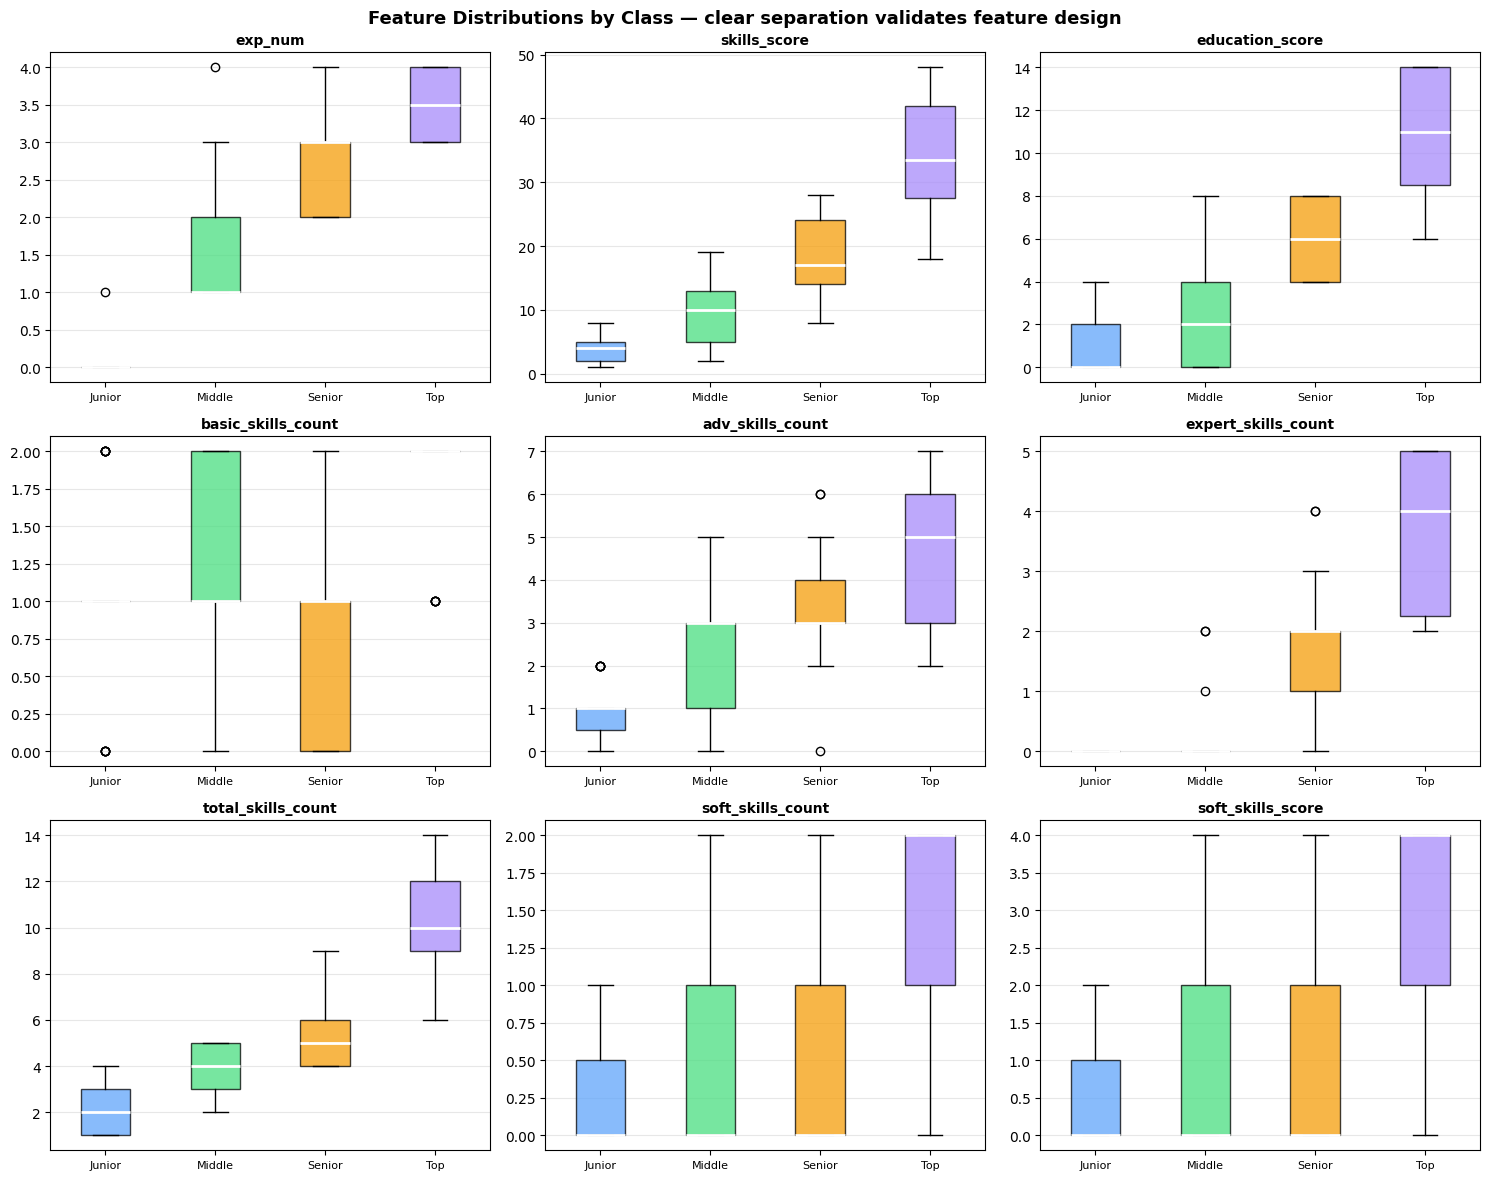

Saved: feature_distributions.png


In [22]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes_flat = axes.flatten()

for i, feat in enumerate(FEATURES):
    ax = axes_flat[i]
    data_by_class = [df[df['label'] == cls][feat].values for cls in CLASS_ORDER]
    bp = ax.boxplot(data_by_class, labels=CLASS_ORDER, patch_artist=True)
    for patch, cls in zip(bp['boxes'], CLASS_ORDER):
        patch.set_facecolor(PALETTE[cls])
        patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set_color('white')
        median.set_linewidth(2)
    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', labelsize=8)

fig.suptitle('Feature Distributions by Class — clear separation validates feature design',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ML_DIR, 'feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

## 4. Feature Correlation Matrix

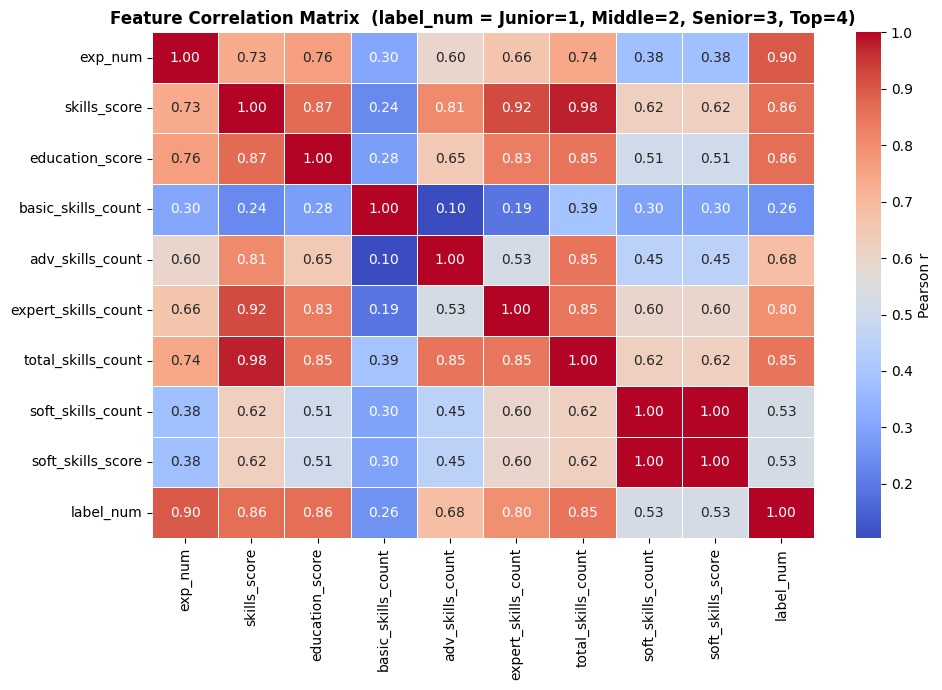

Saved: feature_correlation.png


In [23]:
le = LabelEncoder()
df['label_num'] = le.fit_transform(df['label'])

corr_cols = FEATURES + ['label_num']
plt.figure(figsize=(10, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title('Feature Correlation Matrix  (label_num = Junior=1, Middle=2, Senior=3, Top=4)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(ML_DIR, 'feature_correlation.png'), dpi=150)
plt.show()
print('Saved: feature_correlation.png')

## 5. Train / Test Split

Stratified split ensures each class is proportionally represented in both sets.

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train : {X_train.shape[0]} rows')
print(f'Test  : {X_test.shape[0]} rows')
print(f'\nTrain class distribution:')
print(y_train.value_counts().reindex(CLASS_ORDER))
print(f'\nTest class distribution:')
print(y_test.value_counts().reindex(CLASS_ORDER))

Train : 104 rows
Test  : 27 rows

Train class distribution:
label
Junior    22
Middle    29
Senior    29
Top       24
Name: count, dtype: int64

Test class distribution:
label
Junior    5
Middle    8
Senior    8
Top       6
Name: count, dtype: int64


## 6. Baseline Models

Training with default hyperparameters establishes the baseline **before** tuning.  
Comparing baseline vs tuned quantifies the benefit of GridSearchCV.

In [25]:
# Decision Tree — simpler baseline
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

# Random Forest — default params
rf_default = RandomForestClassifier(n_estimators=100, random_state=42)
rf_default.fit(X_train, y_train)
rf_default_preds = rf_default.predict(X_test)

print('Baseline results (before hyperparameter tuning):')
print('=' * 58)
for name, preds in [('Decision Tree   (max_depth=5)', dt_preds),
                    ('Random Forest   (n_estimators=100)', rf_default_preds)]:
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    print(f'  {name}  Acc: {acc:.2%}   F1: {f1:.2%}')
print('=' * 58)

Baseline results (before hyperparameter tuning):
  Decision Tree   (max_depth=5)  Acc: 77.78%   F1: 77.66%
  Random Forest   (n_estimators=100)  Acc: 81.48%   F1: 81.01%


## 7. GridSearchCV — Hyperparameter Tuning

Exhaustive search over 72 parameter combinations using 5-fold cross-validation.  

| Parameter | Values searched | Rationale |
|---|---|---|
| `n_estimators` | 50, 100, 200 | More trees → lower variance, diminishing returns |
| `max_depth` | None, 5, 10, 15 | Controls overfitting |
| `min_samples_split` | 2, 5, 10 | Minimum samples to split a node |
| `max_features` | sqrt, log2 | Feature subsampling per split |

In [26]:
param_grid = {
    'n_estimators':      [50, 100, 200],
    'max_depth':         [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'max_features':      ['sqrt', 'log2'],
}

print(f'Total combinations: {3*4*3*2} × 5-fold CV = {3*4*3*2*5} fits')
print('Running GridSearchCV... (may take 30–60 seconds)')

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0,
)
grid_search.fit(X_train, y_train)

print(f'\nBest parameters : {grid_search.best_params_}')
print(f'Best CV score   : {grid_search.best_score_:.2%}')

rf = grid_search.best_estimator_
rf_tuned_preds = rf.predict(X_test)

print(f'\nTuned RF  →  Acc: {accuracy_score(y_test, rf_tuned_preds):.2%}   '
      f'F1: {f1_score(y_test, rf_tuned_preds, average="weighted"):.2%}')

Total combinations: 72 × 5-fold CV = 360 fits
Running GridSearchCV... (may take 30–60 seconds)

Best parameters : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 50}
Best CV score   : 91.33%

Tuned RF  →  Acc: 77.78%   F1: 77.66%


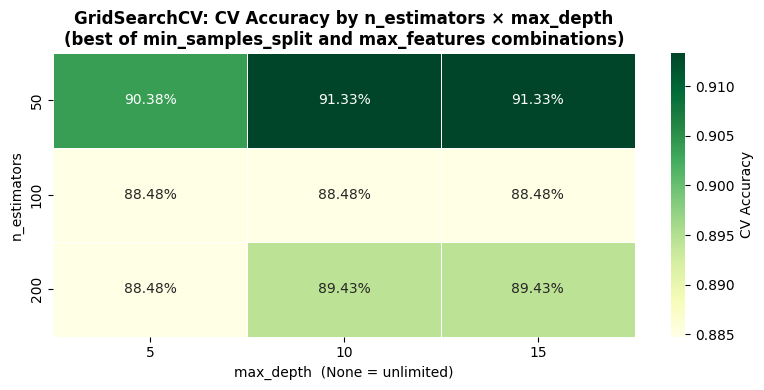

Saved: gridsearch_heatmap.png


In [27]:
# GridSearch heatmap: n_estimators × max_depth
results_df = pd.DataFrame(grid_search.cv_results_)
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_n_estimators',
    columns='param_max_depth',
    aggfunc='max'
)

plt.figure(figsize=(8, 4))
sns.heatmap(pivot, annot=True, fmt='.2%', cmap='YlGn', linewidths=0.5,
            cbar_kws={'label': 'CV Accuracy'})
plt.title('GridSearchCV: CV Accuracy by n_estimators × max_depth\n'
          '(best of min_samples_split and max_features combinations)',
          fontweight='bold')
plt.xlabel('max_depth  (None = unlimited)')
plt.ylabel('n_estimators')
plt.tight_layout()
plt.savefig(os.path.join(ML_DIR, 'gridsearch_heatmap.png'), dpi=150)
plt.show()
print('Saved: gridsearch_heatmap.png')

## 8. Model Comparison

In [28]:
models = {
    'Decision Tree  (baseline, max_depth=5)': dt_preds,
    'Random Forest  (default, n=100)':        rf_default_preds,
    'Random Forest  (GridSearchCV tuned)':    rf_tuned_preds,
}

print(f'{"Model":<45} {"Accuracy":>10} {"F1 (weighted)":>15}')
print('-' * 72)
for name, preds in models.items():
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='weighted')
    print(f'{name:<45} {acc:>10.2%} {f1:>15.2%}')

print('\n' + '─'*50)
print('Classification Report — Tuned Random Forest')
print('─'*50)
print(classification_report(y_test, rf_tuned_preds, target_names=CLASS_ORDER))

Model                                           Accuracy   F1 (weighted)
------------------------------------------------------------------------
Decision Tree  (baseline, max_depth=5)            77.78%          77.66%
Random Forest  (default, n=100)                   81.48%          81.01%
Random Forest  (GridSearchCV tuned)               77.78%          77.66%

──────────────────────────────────────────────────
Classification Report — Tuned Random Forest
──────────────────────────────────────────────────
              precision    recall  f1-score   support

      Junior       1.00      0.80      0.89         5
      Middle       0.58      0.88      0.70         8
      Senior       0.80      0.50      0.62         8
         Top       1.00      1.00      1.00         6

    accuracy                           0.78        27
   macro avg       0.85      0.79      0.80        27
weighted avg       0.82      0.78      0.78        27



## 9. Confusion Matrix

Side-by-side comparison of all three models. Perfect prediction shows values only on the diagonal.

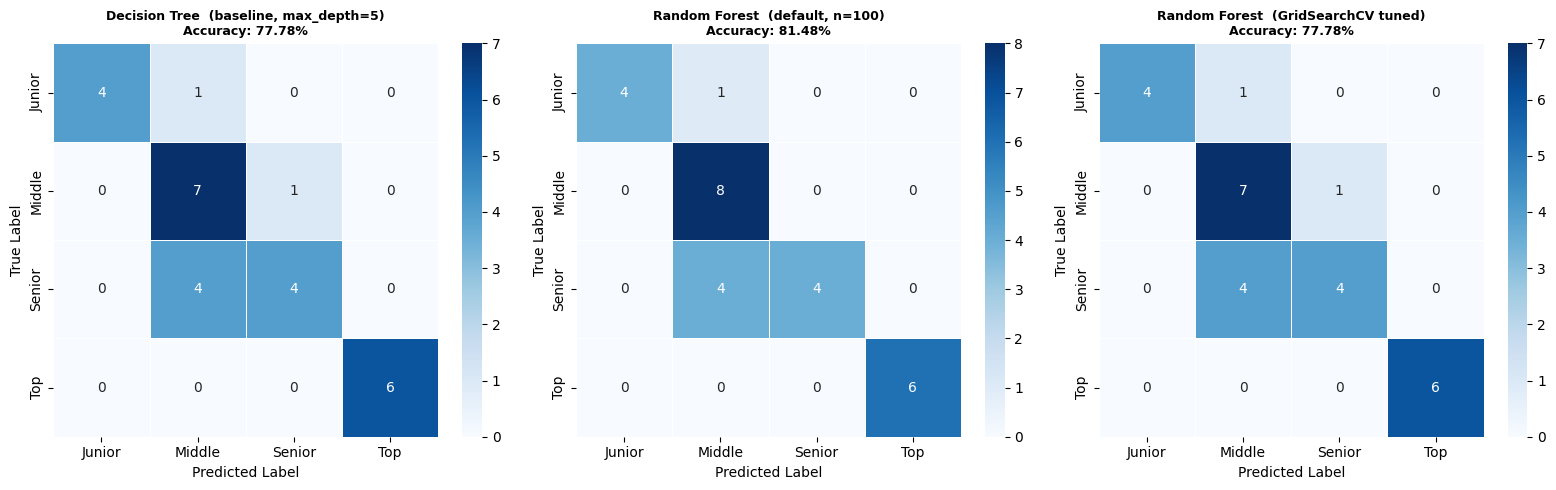

Saved: confusion_matrix.png


In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds, labels=CLASS_ORDER)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
                linewidths=0.5)
    acc = accuracy_score(y_test, preds)
    ax.set_title(f'{name}\nAccuracy: {acc:.2%}',
                 fontweight='bold', fontsize=9)
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig(os.path.join(ML_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()
print('Saved: confusion_matrix.png')

## 10. Error Analysis

Examining misclassified and low-confidence examples reveals where the model struggles —  
typically at class boundaries (Middle/Senior) where feature signals overlap.

In [30]:
probas     = rf.predict_proba(X_test)
confidence = probas.max(axis=1) * 100

results = X_test.copy()
results['true_label'] = y_test.values
results['pred_label'] = rf_tuned_preds
results['confidence'] = confidence.round(1)
results['correct']    = results['true_label'] == results['pred_label']

misclassified = results[~results['correct']]
print(f'Test examples  : {len(results)}')
print(f'Correct        : {results["correct"].sum()} ({results["correct"].mean():.1%})')
print(f'Misclassified  : {len(misclassified)} ({len(misclassified)/len(results):.1%} error rate)')

if len(misclassified) > 0:
    disp_cols = ['true_label', 'pred_label', 'confidence',
                 'exp_num', 'skills_score', 'total_skills_count', 'education_score']
    print('\nMisclassified examples:')
    print(misclassified[disp_cols].to_string())
else:
    print('\nNo misclassifications on the test set.')

low_conf = results[results['confidence'] < 80].sort_values('confidence')
print(f'\nLow-confidence predictions (<80%): {len(low_conf)}')
if len(low_conf) > 0:
    print(low_conf[['true_label', 'pred_label', 'confidence',
                    'exp_num', 'skills_score', 'total_skills_count']].to_string())

Test examples  : 27
Correct        : 21 (77.8%)
Misclassified  : 6 (22.2% error rate)

Misclassified examples:
    true_label pred_label  confidence  exp_num  skills_score  total_skills_count  education_score
123     Senior     Middle        62.1        3             8                   4                4
103     Middle     Senior        65.7        1            19                   5                6
22      Senior     Middle        75.6        3            13                   5                4
6       Senior     Middle        59.3        2            16                   6                4
25      Senior     Middle        65.5        3            11                   5                4
95      Junior     Middle        91.9        1             4                   2                0

Low-confidence predictions (<80%): 9
    true_label pred_label  confidence  exp_num  skills_score  total_skills_count
6       Senior     Middle        59.3        2            16                   6
123

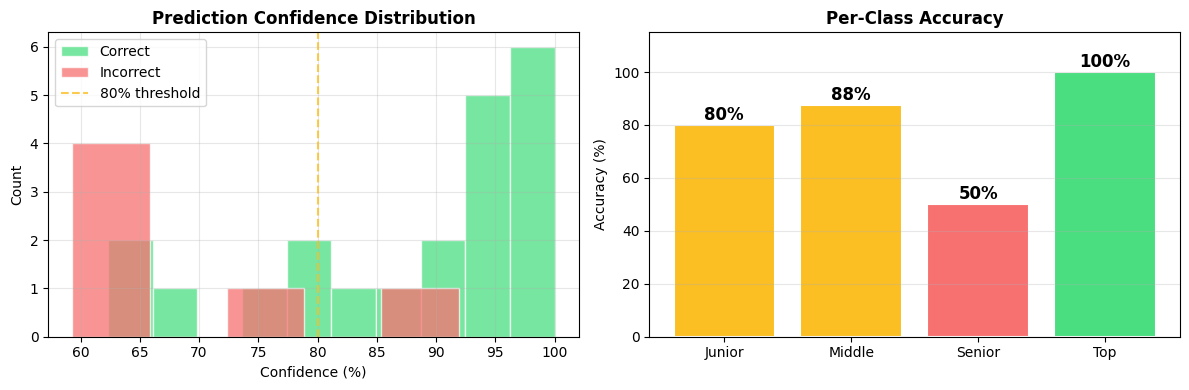

Saved: error_analysis.png


In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confidence distribution: correct vs incorrect
axes[0].hist(results[results['correct']]['confidence'],
             bins=10, alpha=0.75, color='#4ade80',
             label='Correct', edgecolor='white')
if len(misclassified) > 0:
    axes[0].hist(misclassified['confidence'],
                 bins=5, alpha=0.75, color='#f87171',
                 label='Incorrect', edgecolor='white')
axes[0].axvline(80, color='#fbbf24', linestyle='--', alpha=0.8, label='80% threshold')
axes[0].set_xlabel('Confidence (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Prediction Confidence Distribution', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Per-class accuracy
per_class_acc = (results.groupby('true_label')['correct']
                 .mean().reindex(CLASS_ORDER) * 100)
bar_colors = ['#4ade80' if v == 100
              else '#fbbf24' if v >= 80
              else '#f87171'
              for v in per_class_acc.values]
axes[1].bar(per_class_acc.index, per_class_acc.values,
            color=bar_colors, edgecolor='white', linewidth=1.5)
axes[1].set_ylim(0, 115)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Per-Class Accuracy', fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(per_class_acc.values):
    axes[1].text(i, v + 2, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(ML_DIR, 'error_analysis.png'), dpi=150)
plt.show()
print('Saved: error_analysis.png')

## 11. Feature Importance

Random Forest assigns importance scores by measuring how much each feature reduces impurity across all trees.  
Higher importance = stronger signal for class separation.

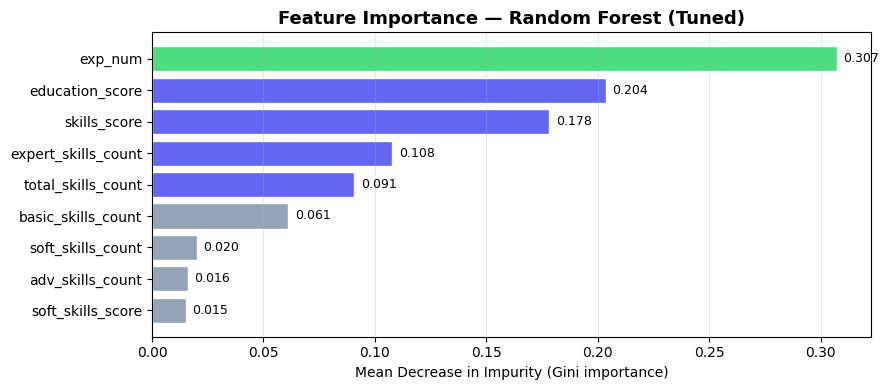

Saved: feature_importance.png


In [32]:
importances = pd.Series(
    rf.feature_importances_, index=FEATURES
).sort_values(ascending=True)

colors = ['#4ade80' if v == importances.max()
          else '#6366f1' if v >= importances.median()
          else '#94a3b8'
          for v in importances.values]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(importances.index, importances.values,
               color=colors, edgecolor='white')
ax.set_xlabel('Mean Decrease in Impurity (Gini importance)')
ax.set_title('Feature Importance — Random Forest (Tuned)',
             fontsize=13, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(ML_DIR, 'feature_importance.png'), dpi=150)
plt.show()
print('Saved: feature_importance.png')

## 12. Learning Curve

Shows how model performance changes as training size increases.  
Converging train/validation lines = good generalisation, no overfitting.

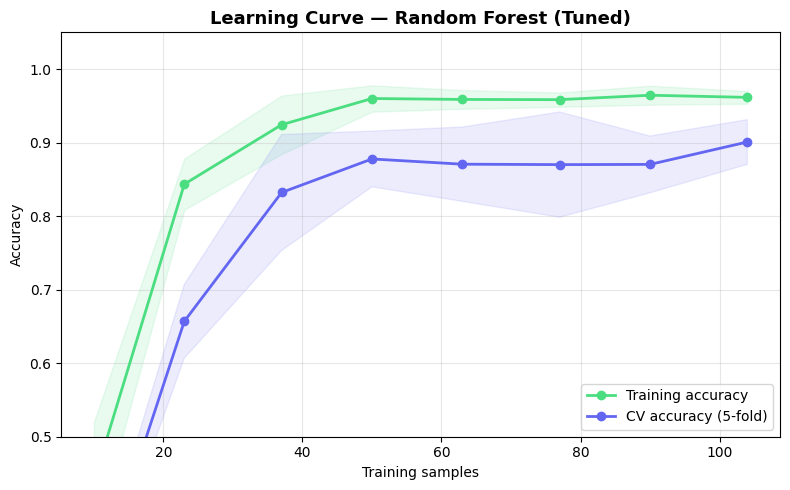

Saved: learning_curve.png


In [33]:
train_sizes, train_scores, val_scores = learning_curve(
    rf, X, y, cv=5, n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='accuracy'
)

tm = train_scores.mean(axis=1); ts = train_scores.std(axis=1)
vm = val_scores.mean(axis=1);   vs_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, tm, 'o-', color='#4ade80', label='Training accuracy', linewidth=2)
plt.fill_between(train_sizes, tm - ts, tm + ts, alpha=0.12, color='#4ade80')
plt.plot(train_sizes, vm, 'o-', color='#6366f1', label='CV accuracy (5-fold)', linewidth=2)
plt.fill_between(train_sizes, vm - vs_std, vm + vs_std, alpha=0.12, color='#6366f1')
plt.xlabel('Training samples')
plt.ylabel('Accuracy')
plt.title('Learning Curve — Random Forest (Tuned)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.ylim(0.5, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(ML_DIR, 'learning_curve.png'), dpi=150)
plt.show()
print('Saved: learning_curve.png')

## 13. Cross-Validation Comparison

5-fold CV gives a robust performance estimate across all data, not just one test split.

5-Fold Cross-Validation Results:
───────────────────────────────────────────────────────
  RF Tuned      89.32% ± 2.86%   scores: [0.889 0.923 0.885 0.846 0.923]
  RF Default    90.88% ± 4.47%   scores: [0.852 0.962 0.885 0.885 0.962]
  Decision Tree  84.73% ± 6.44%   scores: [0.852 0.885 0.731 0.846 0.923]


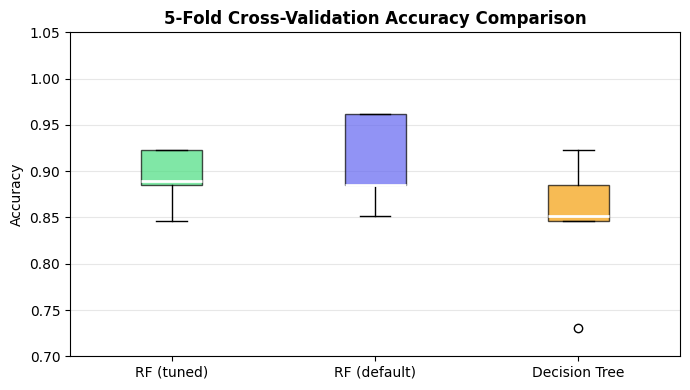

Saved: cv_comparison.png


In [34]:
cv_rf_tuned   = cross_val_score(rf,         X, y, cv=5, scoring='accuracy')
cv_rf_default = cross_val_score(rf_default, X, y, cv=5, scoring='accuracy')
cv_dt         = cross_val_score(dt,         X, y, cv=5, scoring='accuracy')

print('5-Fold Cross-Validation Results:')
print('─' * 55)
for name, scores in [('RF Tuned    ', cv_rf_tuned),
                     ('RF Default  ', cv_rf_default),
                     ('Decision Tree', cv_dt)]:
    print(f'  {name}  {scores.mean():.2%} ± {scores.std():.2%}   scores: {np.round(scores, 3)}')

fig, ax = plt.subplots(figsize=(7, 4))
bp = ax.boxplot(
    [cv_rf_tuned, cv_rf_default, cv_dt],
    labels=['RF (tuned)', 'RF (default)', 'Decision Tree'],
    patch_artist=True
)
colors_box = ['#4ade80', '#6366f1', '#f59e0b']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('white')
    median.set_linewidth(2)
ax.set_title('5-Fold Cross-Validation Accuracy Comparison', fontweight='bold')
ax.set_ylabel('Accuracy')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0.7, 1.05)
plt.tight_layout()
plt.savefig(os.path.join(ML_DIR, 'cv_comparison.png'), dpi=150)
plt.show()
print('Saved: cv_comparison.png')

## 14. Save Tuned Model

In [35]:
joblib.dump(rf, MODEL_PATH)

acc_tuned = accuracy_score(y_test, rf_tuned_preds)
f1_tuned  = f1_score(y_test, rf_tuned_preds, average='weighted')

print(f'Saved: {MODEL_PATH}')
print(f'\n=== Final Model Summary ===')
print(f'Algorithm     : RandomForestClassifier (GridSearchCV tuned)')
print(f'Best params   : {grid_search.best_params_}')
print(f'Best CV acc   : {grid_search.best_score_:.2%}')
print(f'Test accuracy : {acc_tuned:.2%}')
print(f'Weighted F1   : {f1_tuned:.2%}')
print(f'Features      : {FEATURES}')
print(f'\nGenerated PNGs:')
for fname in ['class_distribution.png', 'feature_distributions.png',
              'feature_correlation.png', 'gridsearch_heatmap.png',
              'confusion_matrix.png', 'error_analysis.png',
              'feature_importance.png', 'learning_curve.png',
              'cv_comparison.png']:
    path   = os.path.join(ML_DIR, fname)
    exists = os.path.exists(path)
    size   = f'{os.path.getsize(path):,} bytes' if exists else 'MISSING'
    print(f'  {"✓" if exists else "✗"}  {fname:<35} {size}')

Saved: /Users/mac/backend_fastapi/ml/barber_model.pkl

=== Final Model Summary ===
Algorithm     : RandomForestClassifier (GridSearchCV tuned)
Best params   : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 50}
Best CV acc   : 91.33%
Test accuracy : 77.78%
Weighted F1   : 77.66%
Features      : ['exp_num', 'skills_score', 'education_score', 'basic_skills_count', 'adv_skills_count', 'expert_skills_count', 'total_skills_count', 'soft_skills_count', 'soft_skills_score']

Generated PNGs:
  ✓  class_distribution.png              54,291 bytes
  ✓  feature_distributions.png           128,537 bytes
  ✓  feature_correlation.png             178,318 bytes
  ✓  gridsearch_heatmap.png              59,301 bytes
  ✓  confusion_matrix.png                59,659 bytes
  ✓  error_analysis.png                  57,256 bytes
  ✓  feature_importance.png              54,255 bytes
  ✓  learning_curve.png                  86,199 bytes
  ✓  cv_comparison.png                  

## 15. Live Prediction Tests

Validates the model matches expected business logic:  
- Foundation required (classic or machine)  
- Experience hard cap (0 yrs → max Junior, 1-3 yrs → max Middle, etc.)  
- Salary shown in **KZT/month** (Kazakhstan market 2024-2025)

In [36]:
# Salary ranges in KZT/month — Kazakhstan barbershop market 2024-2025
SALARY_KZT = {
    'Junior': (80_000,   150_000),
    'Middle': (150_000,  300_000),
    'Senior': (300_000,  500_000),
    'Top':    (500_000, 1_000_000),
}
NEXT_LVL    = {'Junior': 'Middle', 'Middle': 'Senior', 'Senior': 'Top', 'Top': None}
LEVEL_ORDER = ['Junior', 'Middle', 'Senior', 'Top']
EXP_CAP     = {'0': 'Junior', '1-3': 'Middle', '3-5': 'Senior', '5-10': 'Top', '10+': 'Top'}
SKILL_FLOOR = {
    'Senior': {'adv': 2, 'expert': 0},
    'Top':    {'adv': 2, 'expert': 2},
}


def predict_barber(years_exp_cat, skills_list, education_count, label=''):
    skls     = set(skills_list)
    exp_num  = EXP_MAP.get(years_exp_cat, 0)
    basic_c  = sum(1 for s in skls if s in BASIC_SKILLS)
    adv_c    = sum(1 for s in skls if s in ADVANCED_SKILLS)
    expert_c = sum(1 for s in skls if s in EXPERT_SKILLS)
    soft_c   = sum(1 for s in skls if s in SOFT_SKILLS)
    total_c  = basic_c + adv_c + expert_c
    s_score  = basic_c * 1 + adv_c * 3 + expert_c * 5
    soft_sc  = soft_c * 2
    edu_s    = education_count * 2

    # Rule 1 — Foundation qualifier
    if basic_c == 0:
        print(f'  Level      : Not Qualified')
        print(f'  Reason     : No foundation skills — classic or machine required')
        return None, 0

    X_pred = pd.DataFrame(
        [[exp_num, s_score, edu_s, basic_c, adv_c, expert_c, total_c, soft_c, soft_sc]],
        columns=FEATURES
    )
    level = rf.predict(X_pred)[0]
    conf  = round(rf.predict_proba(X_pred)[0].max() * 100, 1)

    # Rule 2 — Experience hard cap
    max_lvl  = EXP_CAP.get(years_exp_cat, 'Junior')
    original = level
    if LEVEL_ORDER.index(level) > LEVEL_ORDER.index(max_lvl):
        level = max_lvl
        conf  = round(conf * 0.75, 1)

    # Rule 3 — Skill floor check
    floor = SKILL_FLOOR.get(level)
    if floor and (adv_c < floor['adv'] or expert_c < floor['expert']):
        downgraded = LEVEL_ORDER[LEVEL_ORDER.index(level) - 1]
        print(f'  Level      : {downgraded}  ({conf}% confidence)')
        print(f'  ⚠ Floor    : {level} requires adv>={floor["adv"]}, expert>={floor["expert"]} '
              f'(you have adv={adv_c}, expert={expert_c}) -> downgraded to {downgraded}')
        level = downgraded
    else:
        s_min, s_max = SALARY_KZT[level]
        if original != level:
            print(f'  ⚠ Capped   : model predicted {original} but {years_exp_cat} yr(s) is insufficient')
        print(f'  Level      : {level}  ({conf}% confidence)')
        print(f'  Salary     : {s_min:,} – {s_max:,} KZT/month')
        print(f'  Next level : {NEXT_LVL[level] or "— Already at Top!"}')
    return level, conf


test_cases = [
    ('TEST 1 — Junior (0 exp, basic skills only)',
     '0',   ['classic', 'machine'],                                                           0),
    ('TEST 2 — Middle (1-3 yrs, fade + beard)',
     '1-3', ['classic', 'machine', 'fade', 'beard'],                                         2),
    ('TEST 3 — Middle with trending KZ services (waxing, scissors)',
     '1-3', ['classic', 'machine', 'waxing', 'scissors'],                                    1),
    ('TEST 4 — Senior (3-5 yrs, advanced + coloring)',
     '3-5', ['classic', 'machine', 'fade', 'beard', 'razor', 'coloring'],                    3),
    ('TEST 5 — Top / Master (10+ yrs, full specialist portfolio)',
     '10+', ['classic', 'machine', 'fade', 'beard', 'razor',
              'coloring', 'correction', 'extensions', 'camouflage', 'perm',
              'consulting', 'products'],                                                      7),
    ('TEST 6 — Experience cap (0 yrs but all skills -> must be Junior)',
     '0',   ['classic', 'machine', 'fade', 'beard', 'coloring', 'correction', 'extensions'], 5),
    ('TEST 7 — Stagnant barber (10+ yrs but only classic+machine -> Middle)',
     '10+', ['classic', 'machine'],                                                           1),
    ('TEST 8 — Perm alone != Top (needs full specialist portfolio)',
     '5-10', ['classic', 'fade', 'beard', 'perm', 'waxing'],                                3),
    ('TEST 9 — Soft skills alone do NOT boost level',
     '1-3', ['classic', 'machine', 'consulting', 'products'],                                1),
    ('TEST 10 — Not Qualified (no foundation skills)',
     '5-10', ['fade', 'beard', 'coloring', 'correction'],                                    4),
]

for title, exp, skills, edu in test_cases:
    print(f'\n{title}:')
    predict_barber(exp, skills, edu)


TEST 1 — Junior (0 exp, basic skills only):
  Level      : Junior  (90.4% confidence)
  Salary     : 80,000 – 150,000 KZT/month
  Next level : Middle

TEST 2 — Middle (1-3 yrs, fade + beard):
  Level      : Middle  (74.2% confidence)
  Salary     : 150,000 – 300,000 KZT/month
  Next level : Senior

TEST 3 — Middle with trending KZ services (waxing, scissors):
  Level      : Middle  (77.3% confidence)
  Salary     : 150,000 – 300,000 KZT/month
  Next level : Senior

TEST 4 — Senior (3-5 yrs, advanced + coloring):
  Level      : Senior  (61.5% confidence)
  Salary     : 300,000 – 500,000 KZT/month
  Next level : Top

TEST 5 — Top / Master (10+ yrs, full specialist portfolio):
  Level      : Top  (99.8% confidence)
  Salary     : 500,000 – 1,000,000 KZT/month
  Next level : — Already at Top!

TEST 6 — Experience cap (0 yrs but all skills -> must be Junior):
  ⚠ Capped   : model predicted Top but 0 yr(s) is insufficient
  Level      : Junior  (33.2% confidence)
  Salary     : 80,000 – 150